In [ ]:
# 2025.11.29 LSVM Find HyperOpt & Train Result

In [14]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [15]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets         import make_classification

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.svm            import SVC
from sklearn.metrics        import classification_report
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier

# hyperopt 용
from hyperopt               import hp

# 사용자 Functions import
import importlib
from utils import user_utils
importlib.reload(user_utils)

import HyperParams          as HP 
import utils.data_sampling  as ds 

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [16]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [17]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [18]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [19]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [22]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

# 5.1 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [23]:
# 4.2 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)

# 5.2 Over Sampling한 경우 학습/검증 데이터 분리
X_tr_over, X_val_over, y_tr_over, y_val_over = pp.data_split(X_over, y_over, size=0.4)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [ ]:
# 파라미터 지정 - 에러남
# best_params, best_catboost, trials, exec_time = tuner.tune(
#     lsvc_model, X_tr, y_tr, X_val, y_val, lsvc_search_space
# )

In [24]:
# SVM 중 LinerSVC
from sklearn.svm import LinearSVC

# Search Space 정의
lsvc_search_space = {
    'C': hp.loguniform('C', np.log(0.001), np.log(1000)),
    'class_weight': hp.choice('class_weight', [None, 'balanced']),
    'max_iter': hp.quniform('max_iter', 500, 2000, 500), # 축소, 1000, 10000, 1000),
    'tol': hp.loguniform('tol', np.log(1e-5), np.log(1e-2)),
    'dual': hp.choice('dual', [False, True]),
}

search_result = hyperopt_search(
    model_class = LinearSVC,
    search_space = lsvc_search_space,
    X_train= X_train,
    y_train= y_train,
    max_evals=100,  
    save_trials=True,
    verbose=True
)


  LinearSVC 하이퍼파라미터 탐색 시작
100%|██████████| 100/100 [1:43:54<00:00, 62.34s/trial, best loss: -0.98563755694769]    

탐색 완료 시간: 6234.44초 (103.91분)
최적 roc_auc: 0.9856

최적 하이퍼파라미터:
  - C: 0.0010064028945580546
  - class_weight: 1
  - dual: 0
  - max_iter: 1500
  - tol: 0.00010607856911336914
  - random_state: 23

✓ Trials 객체 저장 완료: ../models/trials/LinearSVC_trials_20251130_010925.pkl


TypeError: Object of type int64 is not JSON serializable

In [34]:
# 사용자 Functions import
import importlib
from utils import hyperopt_search
importlib.reload(hyperopt_search)

from utils.hyperopt_search import extract_best_params_from_trials

# 1. trials 객체 로드
trials_path = '../models/trials/LinearSVC_trials_20251130_010925.pkl'  # 실제 파일명으로 변경

# 2. choice_mappings 올바르게 정의
lsvc_choice_mappings = {
    'class_weight': [None, 'balanced'],
    'dual': [False, True]
}
search_result = extract_best_params_from_trials(
    trials_path=trials_path,
    choice_mappings=lsvc_choice_mappings,
    random_state=23
)

print("Best params:", search_result['best_params'])
print(f"Best score: {search_result['best_score']:.4f}")


Best params: {'C': 0.0010064028945580546, 'class_weight': 'balanced', 'dual': False, 'max_iter': 1500, 'tol': 0.00010607856911336914, 'random_state': 23}
Best score: 0.9856


In [35]:
# 2단계: 최종 학습 및 평가
final_result = train_and_evaluate(
    model_class=LinearSVC,
    params=search_result['best_params'],
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    save_model=True,
    verbose=True
)

print("\n" + "=" * 70)
print("완료!")
print("=" * 70)
print(f"최종 결과: {final_result['result_dict']}")
results['lsvm_ho_best'] = final_result['result_dict']

  LinearSVC 최종 학습 및 평가
사용 파라미터: {'C': 0.0010064028945580546, 'class_weight': 'balanced', 'dual': False, 'max_iter': 1500, 'tol': 0.00010607856911336914, 'random_state': 23}
✓ 학습 완료 (1.94초)

평가 결과:
  - accuracy: 0.9731
  - precision: 0.0541
  - recall: 0.8878
  - f1: 0.1021
  - roc_auc: 0.9684

혼동 행렬:
[[55344  1520]
 [   11    87]]

✓ 모델 저장: ../models/LinearSVC_20251130_014454.pkl (0.00 MB)
✓ 결과 저장: ../results/LinearSVC_result_20251130_014454.json

완료!
최종 결과: {'AUC': 0.9684, '정확도': 0.9731, '정밀도': 0.0541, '재현율': 0.8878, 'F1': 0.1021}


In [36]:
# over sampling 한 경우
final_result_over = train_and_evaluate(
    model_class = LinearSVC,
    params      = search_result['best_params'],
    X_train     = X_over,
    y_train     = y_over,
    X_test      = X_test,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)

print("\n" + "=" * 70)
print("완료!")
print("=" * 70)
print(f"최종 결과: {final_result['result_dict']}")
results['lsvm_ho_best_smote'] = final_result['result_dict']

  LinearSVC 최종 학습 및 평가
사용 파라미터: {'C': 0.0010064028945580546, 'class_weight': 'balanced', 'dual': False, 'max_iter': 1500, 'tol': 0.00010607856911336914, 'random_state': 23}
✓ 학습 완료 (2.40초)

평가 결과:
  - accuracy: 0.9756
  - precision: 0.0594
  - recall: 0.8878
  - f1: 0.1113
  - roc_auc: 0.9671

혼동 행렬:
[[55486  1378]
 [   11    87]]

✓ 모델 저장: ../models/LinearSVC_20251130_014516.pkl (0.00 MB)
✓ 결과 저장: ../results/LinearSVC_result_20251130_014516.json

완료!
최종 결과: {'AUC': 0.9684, '정확도': 0.9731, '정밀도': 0.0541, '재현율': 0.8878, 'F1': 0.1021}


In [37]:
# StandardScale한 경우

X_train_sscaled, X_test_sscaled, scaler = pp.scale_data(X_train, X_test)

ss_result = train_and_evaluate(
    model_class = LinearSVC,
    params      = search_result['best_params'],
    X_train     = X_train_sscaled,
    y_train     = y_train,
    X_test      = X_test_sscaled,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)
results['lsvm_ho_best_sscaled'] = ss_result['result_dict'] 


  LinearSVC 최종 학습 및 평가
사용 파라미터: {'C': 0.0010064028945580546, 'class_weight': 'balanced', 'dual': False, 'max_iter': 1500, 'tol': 0.00010607856911336914, 'random_state': 23}
✓ 학습 완료 (1.28초)

평가 결과:
  - accuracy: 0.9732
  - precision: 0.0543
  - recall: 0.8878
  - f1: 0.1023
  - roc_auc: 0.9680

혼동 행렬:
[[55348  1516]
 [   11    87]]

✓ 모델 저장: ../models/LinearSVC_20251130_014522.pkl (0.00 MB)
✓ 결과 저장: ../results/LinearSVC_result_20251130_014522.json


In [38]:
# Data Scale2 
from sklearn.preprocessing import RobustScaler

rscaler = RobustScaler()
X_train_rscaled = rscaler.fit_transform(X_train)   # 학습 데이터로 fit + transform
X_test_rscaled = rscaler.transform(X_test)         # 테스트 데이터는 transform만

rs_result = uu.train_and_evaluate(
    model_class = LinearSVC,
    params      = search_result['best_params'],
    X_train     = X_train_rscaled,
    y_train     = y_train,
    X_test      = X_test_rscaled,
    y_test      = y_test,
    save_model  = True,
    verbose     = True
)
results['sgd_ho_best_rscaled'] = rs_result['result_dict']

  LinearSVC 최종 학습 및 평가
사용 파라미터: {'C': 0.0010064028945580546, 'class_weight': 'balanced', 'dual': False, 'max_iter': 1500, 'tol': 0.00010607856911336914, 'random_state': 23}
✓ 학습 완료 (1.24초)

평가 결과:
  - accuracy: 0.9732
  - precision: 0.0542
  - recall: 0.8878
  - f1: 0.1022
  - roc_auc: 0.9682

혼동 행렬:
[[55346  1518]
 [   11    87]]

✓ 모델 저장: ../models/LinearSVC_20251130_014528.pkl (0.00 MB)
✓ 결과 저장: ../results/LinearSVC_result_20251130_014528.json


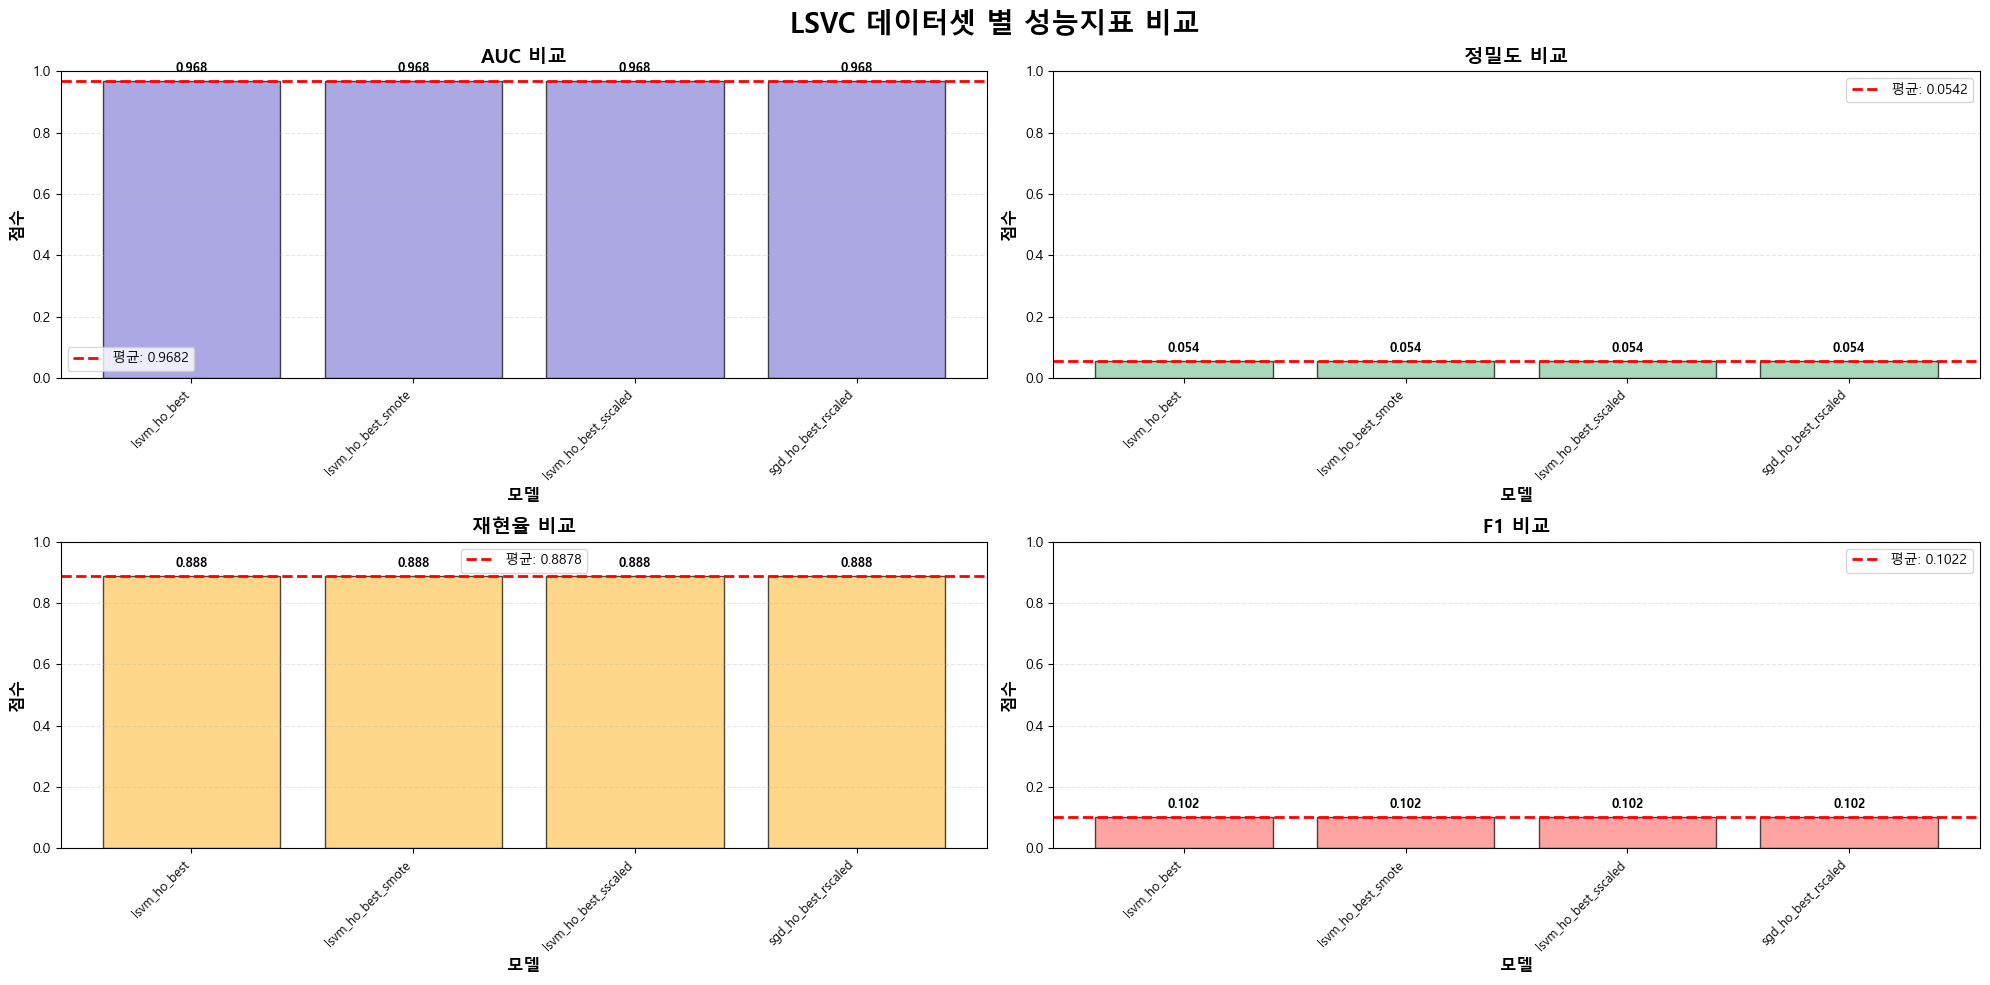


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9684 (lsvm_ho_best)
  최저: 0.9680 (lsvm_ho_best_sscaled)
  평균: 0.9682
  표준편차: 0.0002

[정밀도]
  최고: 0.0543 (lsvm_ho_best_sscaled)
  최저: 0.0541 (lsvm_ho_best)
  평균: 0.0542
  표준편차: 0.0001

[재현율]
  최고: 0.8878 (lsvm_ho_best)
  최저: 0.8878 (lsvm_ho_best)
  평균: 0.8878
  표준편차: 0.0000

[F1]
  최고: 0.1023 (lsvm_ho_best_sscaled)
  최저: 0.1021 (lsvm_ho_best)
  평균: 0.1022
  표준편차: 0.0001


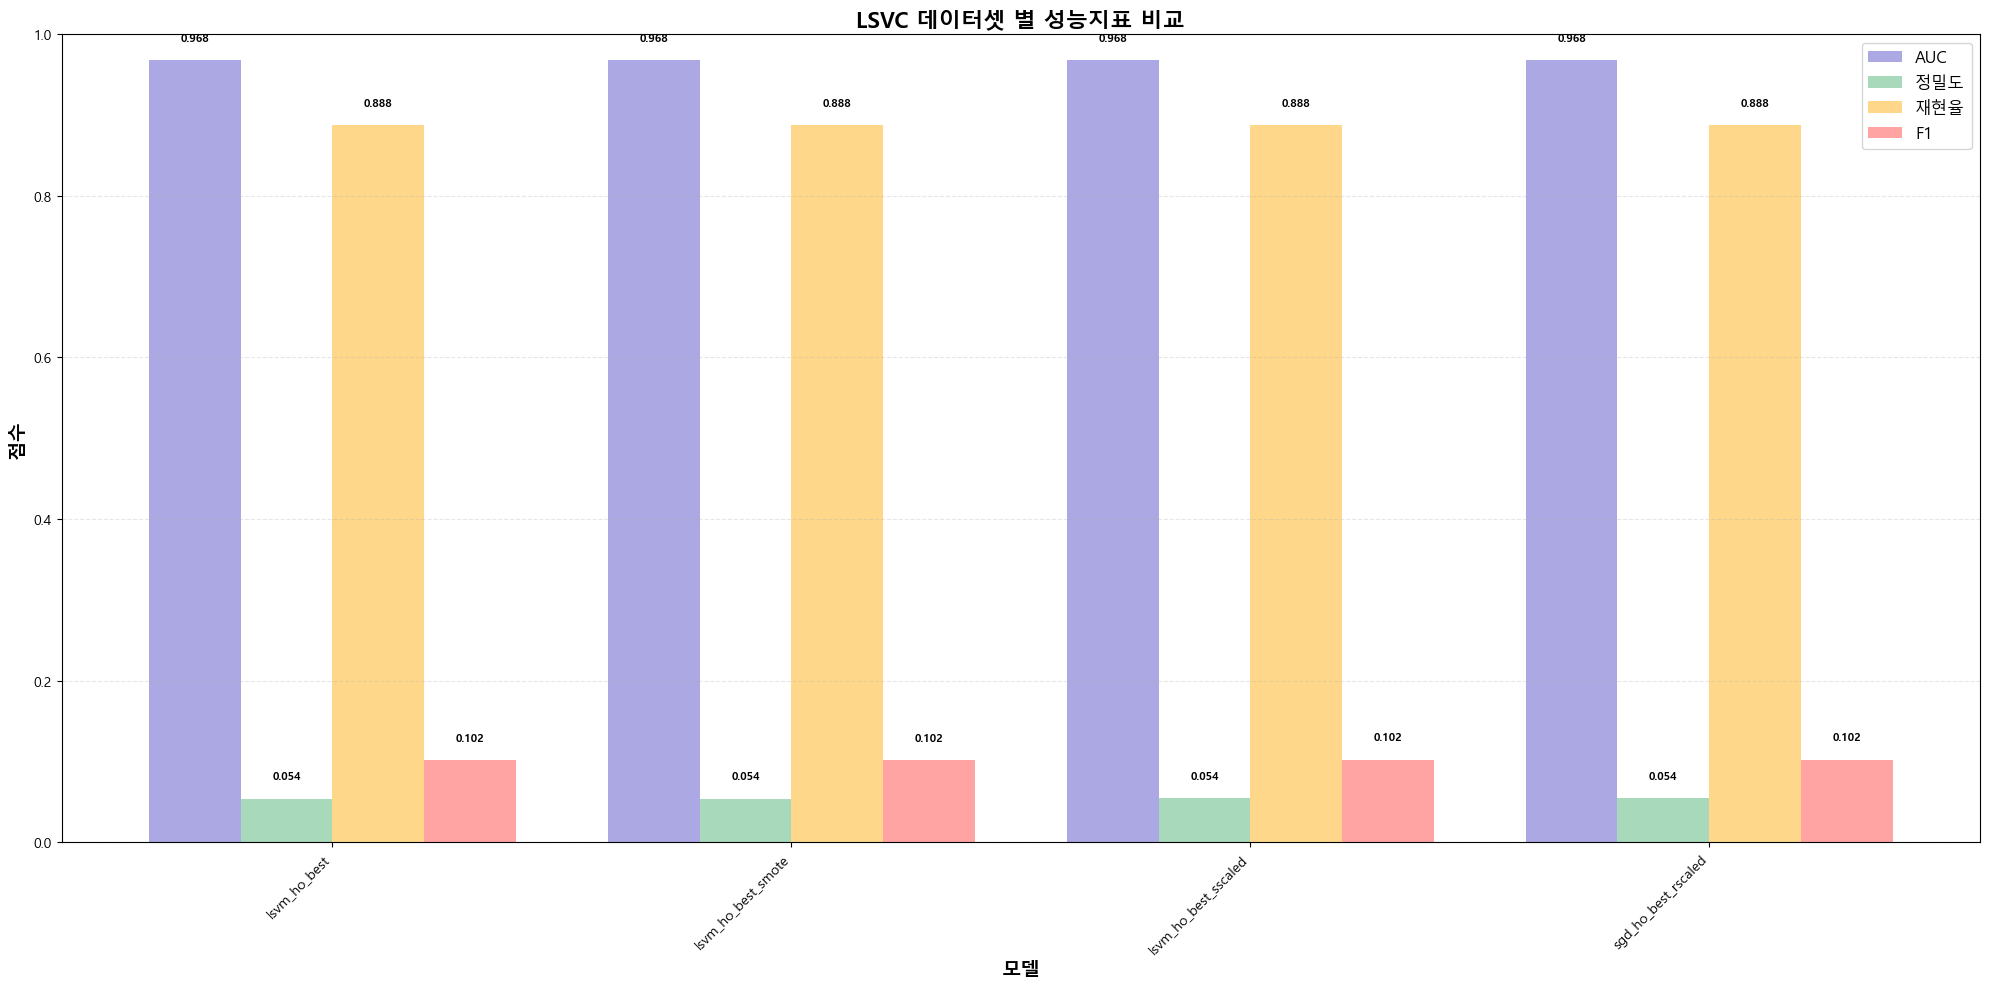


=== F1 Score 기준 상위 5개 모델 ===
                         AUC     정밀도     재현율      F1
lsvm_ho_best_sscaled  0.9680  0.0543  0.8878  0.1023
sgd_ho_best_rscaled   0.9682  0.0542  0.8878  0.1022
lsvm_ho_best_smote    0.9684  0.0541  0.8878  0.1021
lsvm_ho_best          0.9684  0.0541  0.8878  0.1021

=== AUC 기준 상위 5개 모델 ===
                         AUC     정밀도     재현율      F1
lsvm_ho_best          0.9684  0.0541  0.8878  0.1021
lsvm_ho_best_smote    0.9684  0.0541  0.8878  0.1021
sgd_ho_best_rscaled   0.9682  0.0542  0.8878  0.1022
lsvm_ho_best_sscaled  0.9680  0.0543  0.8878  0.1023

그래프가 저장되었습니다: ../images/LSVC_데이터셋_별_성능지표_비교_2025_1130.png


In [39]:
# 7 시각화
mo.model_metrics_graph(results, 'LSVC 데이터셋 별 성능지표 비교')

In [ ]:
# error version
# from sklearn.svm            import LinearSVC

# # lsvc_model = LinearSVC(random_state=team_rs)
# lsvc_search_space = {
#     'C': hp.loguniform('C', np.log(0.001), np.log(1000)),  # 정규화 강도 (작을수록 강한 정규화)
#     'class_weight': hp.choice('class_weight', [None, 'balanced']),  # 클래스 가중치
#     'max_iter': hp.quniform('max_iter', 1000, 10000, 1000),  # 최대 반복 횟수
#     'tol': hp.loguniform('tol', np.log(1e-5), np.log(1e-2)),  # 수렴 허용 오차
#     'dual': hp.choice('dual', [False, True]),  # dual formulation (n_samples > n_features일 때 False 권장)
# }

# # HyperOpt 실행
# result = hyperopt_tune(
#     model_class = LinearSVC,
#     search_space=lsvc_search_space,
#     X_train=X_train,
#     y_train=y_train,
#     X_test=X_test,
#     y_test=y_test,
# )
    
# # 결과 사용
# best_model = result['model']
# best_params = result['best_params']
# print("\n최종 결과:", result['result_dict'])
errorMsg= ''' 
==================================================
  LinearSVC 튜닝 시작
==================================================
100%|██████████| 100/100 [4:45:50<00:00, 171.51s/trial, best loss: -0.9856408454483058]  
튜닝 시간: 17150.66초
최적 roc_auc: 0.9856

---------------------------------------------------------------------------
InvalidParameterError                     Traceback (most recent call last)
Cell In[18], line 13
      4 lsvc_search_space = {
      5     'C': hp.loguniform('C', np.log(0.001), np.log(1000)),  # 정규화 강도 (작을수록 강한 정규화)
      6     'class_weight': hp.choice('class_weight', [None, 'balanced']),  # 클래스 가중치
   (...)      9     'dual': hp.choice('dual', [False, True]),  # dual formulation (n_samples > n_features일 때 False 권장)
     10 }
     12 # HyperOpt 실행
---> 13 result = hyperopt_tune(
     14     model_class = LinearSVC,
     15     search_space=lsvc_search_space,
     16     X_train=X_train,
     17     y_train=y_train,
     18     X_test=X_test,
     19     y_test=y_test,
     20 )
     22 # 결과 사용
     23 best_model = result['model']

Cell In[16], line 201, in hyperopt_tune(model_class, search_space, X_train, y_train, X_test, y_test, max_evals, cv, scoring, random_state, is_save_model, verbose)
    199 # 최종 모델 학습
    200 final_model = model_class(**final_params)
--> 201 final_model.fit(X_train, y_train)
    203 # 예측
    204 y_pred = final_model.predict(X_test)

File c:\Users\user\anaconda3\envs\ml_dev\Lib\site-packages\sklearn\base.py:1358, in _fit_context.<locals>.decorator.<locals>.wrapper(estimator, *args, **kwargs)
   1353 partial_fit_and_fitted = (
   1354     fit_method.__name__ == "partial_fit" and _is_fitted(estimator)
   1355 )
   1357 if not global_skip_validation and not partial_fit_and_fitted:
-> 1358     estimator._validate_params()
   1360 with config_context(
   1361     skip_parameter_validation=(
   1362         prefer_skip_nested_validation or global_skip_validation
   1363     )
   1364 ):
   1365     return fit_method(estimator, *args, **kwargs)

File c:\Users\user\anaconda3\envs\ml_dev\Lib\site-packages\sklearn\base.py:471, in BaseEstimator._validate_params(self)
    463 def _validate_params(self):
    464     """Validate types and values of constructor parameters
    465 
    466     The expected type and values must be defined in the `_parameter_constraints`
   (...)    469     accepted constraints.
    470     """
--> 471     validate_parameter_constraints(
    472         self._parameter_constraints,
    473         self.get_params(deep=False),
    474         caller_name=self.__class__.__name__,
    475     )

File c:\Users\user\anaconda3\envs\ml_dev\Lib\site-packages\sklearn\utils\_param_validation.py:98, in validate_parameter_constraints(parameter_constraints, params, caller_name)
     92 else:
     93     constraints_str = (
     94         f"{', '.join([str(c) for c in constraints[:-1]])} or"
     95         f" {constraints[-1]}"
     96     )
---> 98 raise InvalidParameterError(
     99     f"The {param_name!r} parameter of {caller_name} must be"
    100     f" {constraints_str}. Got {param_val!r} instead."
    101 )

InvalidParameterError: The 'class_weight' parameter of LinearSVC must be None, an instance of 'dict' or a str among {'balanced'}. Got 1.0 instead.
'''